# Week 15 Demo: LungFunc 线性模型案例

本 Notebook 配套第15周课件，用同一份 `LungFunc_case_data.csv` 演示：

- 简单线性模型：`LungFunc ~ Age`
- 多元线性模型：`LungFunc ~ Age + Gender + Smoking`
- 一般线性模型：把性别、吸烟状态作为类别因素进入模型
- 模型假设检查、模型评价、结果汇报

变量编码：

- `Gender`: 0 = Female, 1 = Male
- `Smoking`: 0 = Non-smoker, 1 = Smoker


## 1. 准备环境与读取数据

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

plt.rcParams.update({
    "figure.figsize": (7.2, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_PATH = Path("LungFunc_case_data.csv")
df = pd.read_csv(DATA_PATH)

# 类别变量编码
df["GenderLabel"] = df["Gender"].map({0: "Female", 1: "Male"})
df["SmokingLabel"] = df["Smoking"].map({0: "Non-smoker", 1: "Smoker"})

df.head()

,ID,Age,Gender,Smoking,LungFunc,GenderLabel,SmokingLabel
0,1,45,1,1,80,Male,Smoker
1,2,32,0,0,95,Female,Non-smoker
2,3,55,1,1,68,Male,Smoker
3,4,41,0,0,102,Female,Non-smoker
4,5,28,1,1,75,Male,Smoker


In [2]:
print(f"n = {len(df)}")
df.describe(include="all")

n = 30


,ID,Age,Gender,Smoking,LungFunc,GenderLabel,SmokingLabel
count,30.000000,30.000000,30.000000,30.000000,30.000000,30,30
unique,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,NaN,Male,Smoker
freq,NaN,NaN,NaN,NaN,NaN,15,17
mean,15.500000,41.833333,0.500000,0.566667,86.333333,NaN,NaN
std,8.803408,8.416254,0.508548,0.504007,9.914578,NaN,NaN
min,1.000000,28.000000,0.000000,0.000000,68.000000,NaN,NaN
25%,8.250000,35.250000,0.000000,0.000000,79.250000,NaN,NaN
50%,15.500000,41.500000,0.500000,1.000000,87.500000,NaN,NaN
75%,22.750000,48.750000,1.000000,1.000000,93.750000,NaN,NaN


## 2. 先看数据：一个解释变量够不够？

课堂讨论：

1. 只看 `Age` 与 `LungFunc` 的关系，你会得出什么结论？
2. 加上吸烟状态后，图形是否改变了你的判断？
3. 这说明为什么需要多元线性模型？


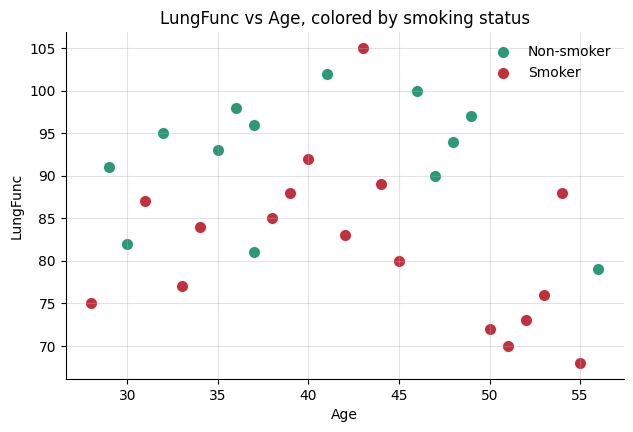

In [3]:
fig, ax = plt.subplots()
colors = {"Non-smoker": "#168C67", "Smoker": "#B71C2B"}

for label, sub in df.groupby("SmokingLabel"):
    ax.scatter(
        sub["Age"],
        sub["LungFunc"],
        label=label,
        color=colors[label],
        edgecolor="white",
        s=80,
        alpha=0.9,
    )

ax.set_title("LungFunc vs Age, colored by smoking status")
ax.set_xlabel("Age")
ax.set_ylabel("LungFunc")
ax.legend(frameon=False)
plt.show()

## 3. 简单线性模型：`LungFunc ~ Age`

In [4]:
slm_age = smf.ols("LungFunc ~ Age", data=df).fit()
print(slm_age.summary())

                            OLS Regression Results                            
Dep. Variable:               LungFunc   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.087
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.160
Time:                        10:14:44   Log-Likelihood:                -109.80
No. Observations:                  30   AIC:                             223.6
Df Residuals:                      28   BIC:                             226.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     99.3127      9.158     10.844      0.0

Estimated equation: LungFunc_hat = 99.31 + (-0.31) * Age


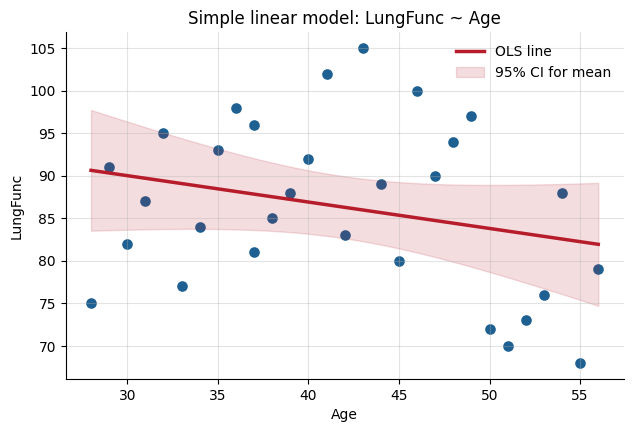

In [5]:
b0, b1 = slm_age.params["Intercept"], slm_age.params["Age"]
print(f"Estimated equation: LungFunc_hat = {b0:.2f} + ({b1:.2f}) * Age")

fig, ax = plt.subplots()
ax.scatter(df["Age"], df["LungFunc"], color="#1E6091", edgecolor="white", s=75)

age_grid = pd.DataFrame({"Age": np.linspace(df["Age"].min(), df["Age"].max(), 100)})
pred = slm_age.get_prediction(age_grid).summary_frame(alpha=0.05)

ax.plot(age_grid["Age"], pred["mean"], color="#B71C2B", linewidth=2.5, label="OLS line")
ax.fill_between(age_grid["Age"], pred["mean_ci_lower"], pred["mean_ci_upper"], color="#B71C2B", alpha=0.15, label="95% CI for mean")
ax.set_title("Simple linear model: LungFunc ~ Age")
ax.set_xlabel("Age")
ax.set_ylabel("LungFunc")
ax.legend(frameon=False)
plt.show()

**解释提醒**

简单线性模型只能回答“年龄与肺功能的粗略关系”。如果吸烟、性别也和肺功能有关，那么单变量斜率可能混合了其它变量的影响。


## 4. 多元线性模型：`LungFunc ~ Age + Gender + Smoking`

In [6]:
mlm = smf.ols("LungFunc ~ Age + Gender + Smoking", data=df).fit()
print(mlm.summary())

                            OLS Regression Results                            
Dep. Variable:               LungFunc   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     4.720
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00926
Time:                        10:14:44   Log-Likelihood:                -104.36
No. Observations:                  30   AIC:                             216.7
Df Residuals:                      26   BIC:                             222.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    102.0942      8.003     12.756      0.0

### 4.1 矩阵 OLS：手算结果与 statsmodels 一致

In [7]:
X = sm.add_constant(df[["Age", "Gender", "Smoking"]], has_constant="add")
y = df["LungFunc"]

beta_manual = np.linalg.inv(X.T @ X) @ (X.T @ y)
statsmodels_terms = ["Intercept", "Age", "Gender", "Smoking"]

pd.DataFrame({
    "term": X.columns,
    "manual_OLS": beta_manual,
    "statsmodels": mlm.params[statsmodels_terms].to_numpy(),
    "difference": beta_manual - mlm.params[statsmodels_terms].to_numpy(),
})

,term,manual_OLS,statsmodels,difference
0,const,102.094248,102.094248,1.847411e-13
1,Age,-0.179559,-0.179559,-1.082467e-14
2,Gender,-4.414463,-4.414463,-4.440892e-15
3,Smoking,-10.662562,-10.662562,0.000000e+00


矩阵推导的核心：

\[
RSS(\beta)=(Y-X\beta)'(Y-X\beta)
\]

\[
\frac{\partial RSS}{\partial \beta}=-2X'Y+2X'X\beta=0
\]

\[
X'X\hat{\beta}=X'Y,
\qquad
\hat{\beta}=(X'X)^{-1}X'Y
\]


### 4.2 系数、置信区间与 p 值

In [8]:
coef_table = pd.DataFrame({
    "coef": mlm.params,
    "std_error": mlm.bse,
    "t": mlm.tvalues,
    "p_value": mlm.pvalues,
    "ci_low": mlm.conf_int()[0],
    "ci_high": mlm.conf_int()[1],
})
coef_table.round(3)

,coef,std_error,t,p_value,ci_low,ci_high
Intercept,102.094,8.003,12.756,0.000,85.643,118.545
Age,-0.180,0.190,-0.945,0.353,-0.570,0.211
Gender,-4.414,3.165,-1.395,0.175,-10.920,2.091
Smoking,-10.663,3.229,-3.302,0.003,-17.299,-4.026


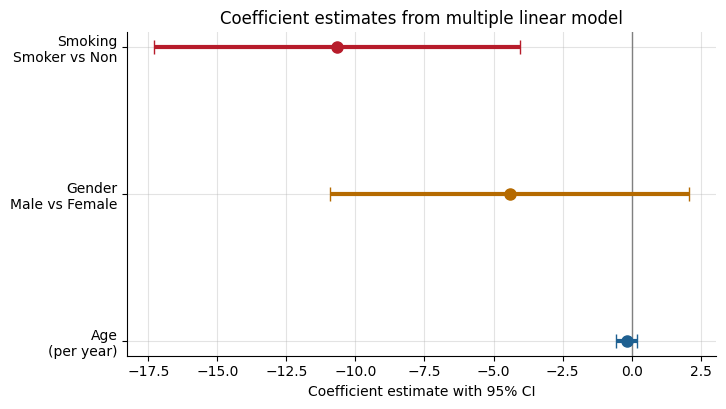

In [9]:
terms = ["Age", "Gender", "Smoking"]
labels = ["Age\n(per year)", "Gender\nMale vs Female", "Smoking\nSmoker vs Non"]
colors = ["#1E6091", "#B56A00", "#B71C2B"]
ci = mlm.conf_int().loc[terms]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.axvline(0, color="gray", linewidth=1)

for i, term in enumerate(terms):
    estimate = mlm.params[term]
    ax.errorbar(
        estimate,
        i,
        xerr=[[estimate - ci.loc[term, 0]], [ci.loc[term, 1] - estimate]],
        fmt="o",
        color=colors[i],
        ecolor=colors[i],
        elinewidth=3,
        capsize=5,
        markersize=8,
    )

ax.set_yticks(range(len(terms)))
ax.set_yticklabels(labels)
ax.set_xlabel("Coefficient estimate with 95% CI")
ax.set_title("Coefficient estimates from multiple linear model")
plt.show()

**一条推荐汇报句式**

在该样本和模型中，控制年龄与性别后，吸烟者的平均肺功能分数比不吸烟者低约 10.66 分，95% CI \[-17.30, -4.03\]，p = 0.003。这个表述是关联，不是因果结论。


### 4.3 图示“控制其他变量后”的调整后效应

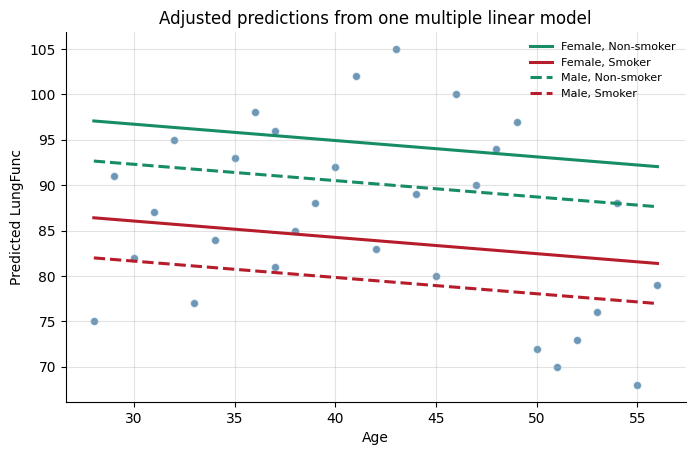

In [10]:
age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 100)
grid = pd.DataFrame({
    "Age": np.tile(age_grid, 4),
    "Gender": np.repeat([0, 0, 1, 1], len(age_grid)),
    "Smoking": np.repeat([0, 1, 0, 1], len(age_grid)),
})
grid["GenderLabel"] = grid["Gender"].map({0: "Female", 1: "Male"})
grid["SmokingLabel"] = grid["Smoking"].map({0: "Non-smoker", 1: "Smoker"})
grid["Pred"] = mlm.predict(grid)

fig, ax = plt.subplots(figsize=(8, 4.8))
for (gender, smoking), sub in grid.groupby(["GenderLabel", "SmokingLabel"]):
    color = "#B71C2B" if smoking == "Smoker" else "#168C67"
    linestyle = "--" if gender == "Male" else "-"
    ax.plot(sub["Age"], sub["Pred"], color=color, linestyle=linestyle, linewidth=2.2, label=f"{gender}, {smoking}")

ax.scatter(df["Age"], df["LungFunc"], color="#1E6091", edgecolor="white", alpha=0.65)
ax.set_title("Adjusted predictions from one multiple linear model")
ax.set_xlabel("Age")
ax.set_ylabel("Predicted LungFunc")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 5. 一般线性模型：类别因素的表达方式

在一般线性模型框架中，连续变量和类别因素可以放在同一个线性模型里。这里把 `GenderLabel` 和 `SmokingLabel` 作为类别因素写进公式：

\[
LungFunc = \beta_0 + \beta_1 Age + \text{Gender factor} + \text{Smoking factor} + \epsilon
\]

对于二分类变量，这与 0/1 编码的多元线性模型在数值上等价，只是输出中的变量名更接近“组间比较”。


In [11]:
glm_cat = smf.ols("LungFunc ~ Age + C(GenderLabel) + C(SmokingLabel)", data=df).fit()
print(glm_cat.summary())

                            OLS Regression Results                            
Dep. Variable:               LungFunc   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     4.720
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00926
Time:                        10:14:44   Log-Likelihood:                -104.36
No. Observations:                  30   AIC:                             216.7
Df Residuals:                      26   BIC:                             222.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [12]:
pd.DataFrame({
    "term_concept": ["Intercept", "Age", "Male vs Female", "Smoker vs Non-smoker"],
    "MLM_numeric_0_1_coding": [
        mlm.params["Intercept"],
        mlm.params["Age"],
        mlm.params["Gender"],
        mlm.params["Smoking"],
    ],
    "GLM_categorical_factor": [
        glm_cat.params["Intercept"],
        glm_cat.params["Age"],
        glm_cat.params["C(GenderLabel)[T.Male]"],
        glm_cat.params["C(SmokingLabel)[T.Smoker]"],
    ],
}).round(3)

,term_concept,MLM_numeric_0_1_coding,GLM_categorical_factor
0,Intercept,102.094,102.094
1,Age,-0.180,-0.180
2,Male vs Female,-4.414,-4.414
3,Smoker vs Non-smoker,-10.663,-10.663


In [13]:
anova_lm(glm_cat, typ=2)

,sum_sq,df,F,PR(>F)
C(GenderLabel),138.081411,1.0,1.945280,0.174899
C(SmokingLabel),774.092537,1.0,10.905357,0.002792
Age,63.355980,1.0,0.892554,0.353484
Residual,1845.552196,26.0,NaN,NaN


**如何读类别因素系数**

statsmodels 会自动选择一个参考组。比如 `C(SmokingLabel)[T.Smoker]` 表示：在控制其它变量后，Smoker 相对于参考组 Non-smoker 的平均差异。


## 6. 模型评价：不要只看一个数字

In [14]:
models = {
    "SLM: Age": slm_age,
    "MLM: Age + Smoking": smf.ols("LungFunc ~ Age + Smoking", data=df).fit(),
    "MLM: Age + Gender + Smoking": mlm,
    "GLM: Age + categorical factors": glm_cat,
}

def rmse(model):
    return np.sqrt(np.mean(model.resid ** 2))

model_eval = pd.DataFrame({
    name: {
        "n": int(model.nobs),
        "df_model": int(model.df_model),
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "F": model.fvalue,
        "Prob_F": model.f_pvalue,
        "AIC": model.aic,
        "BIC": model.bic,
        "RMSE": rmse(model),
    }
    for name, model in models.items()
}).T

model_eval.round(3)

,n,df_model,R2,Adj_R2,F,Prob_F,AIC,BIC,RMSE
SLM: Age,30.0,1.0,0.069,0.036,2.087,0.160,223.603,226.405,9.404
MLM: Age + Smoking,30.0,2.0,0.304,0.253,5.901,0.007,216.881,221.085,8.131
MLM: Age + Gender + Smoking,30.0,3.0,0.353,0.278,4.720,0.009,216.716,222.321,7.843
GLM: Age + categorical factors,30.0,3.0,0.353,0.278,4.720,0.009,216.716,222.321,7.843


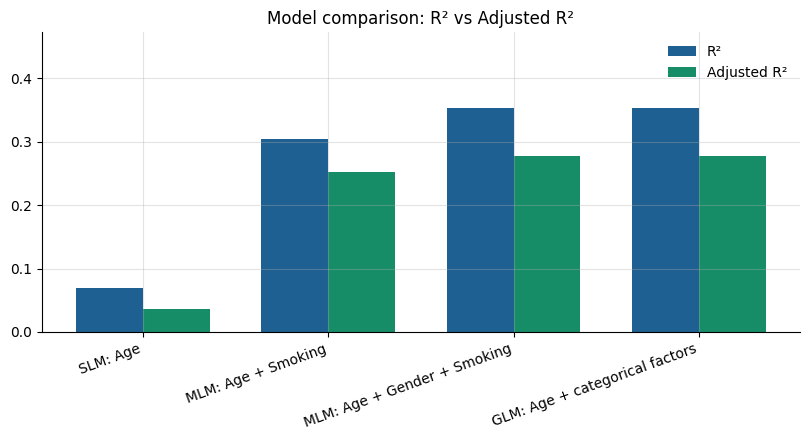

In [15]:
plot_eval = model_eval.reset_index().rename(columns={"index": "Model"})

fig, ax = plt.subplots(figsize=(8.2, 4.5))
x = np.arange(len(plot_eval))
width = 0.36
ax.bar(x - width / 2, plot_eval["R2"], width, label="R²", color="#1E6091")
ax.bar(x + width / 2, plot_eval["Adj_R2"], width, label="Adjusted R²", color="#168C67")
ax.set_xticks(x)
ax.set_xticklabels(plot_eval["Model"], rotation=20, ha="right")
ax.set_ylim(0, max(plot_eval["R2"].max(), plot_eval["Adj_R2"].max()) + 0.12)
ax.set_title("Model comparison: R² vs Adjusted R²")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. 假设条件与诊断图

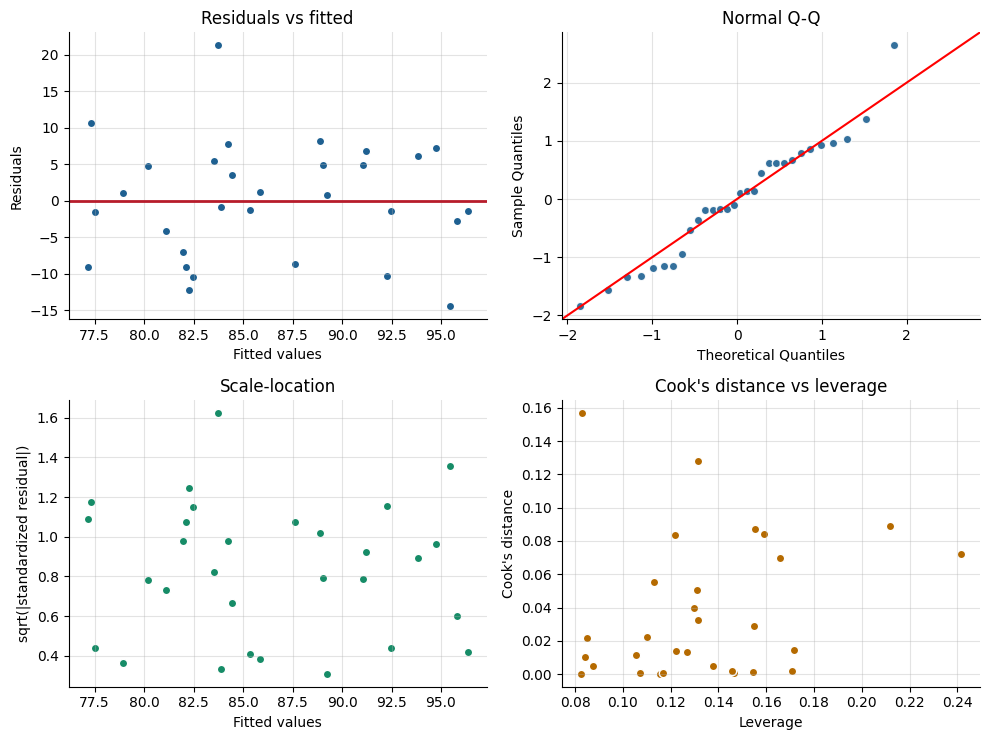

In [16]:
def diagnostic_plots(model):
    fitted = model.fittedvalues
    resid = model.resid
    std_resid = model.get_influence().resid_studentized_internal

    fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

    axes[0, 0].scatter(fitted, resid, color="#1E6091", edgecolor="white")
    axes[0, 0].axhline(0, color="#B71C2B", linewidth=2)
    axes[0, 0].set_title("Residuals vs fitted")
    axes[0, 0].set_xlabel("Fitted values")
    axes[0, 0].set_ylabel("Residuals")

    qqplot(std_resid, line="45", ax=axes[0, 1], markerfacecolor="#1E6091", markeredgecolor="white", alpha=0.9)
    axes[0, 1].set_title("Normal Q-Q")

    axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), color="#168C67", edgecolor="white")
    axes[1, 0].set_title("Scale-location")
    axes[1, 0].set_xlabel("Fitted values")
    axes[1, 0].set_ylabel("sqrt(|standardized residual|)")

    influence = OLSInfluence(model)
    leverage = influence.hat_matrix_diag
    cooks = influence.cooks_distance[0]
    axes[1, 1].scatter(leverage, cooks, color="#B56A00", edgecolor="white")
    axes[1, 1].set_title("Cook's distance vs leverage")
    axes[1, 1].set_xlabel("Leverage")
    axes[1, 1].set_ylabel("Cook's distance")

    plt.tight_layout()
    plt.show()

diagnostic_plots(mlm)

In [17]:
bp = het_breuschpagan(mlm.resid, mlm.model.exog)
diagnostics = pd.Series({
    "Durbin-Watson": durbin_watson(mlm.resid),
    "Shapiro-Wilk W": st.shapiro(mlm.resid).statistic,
    "Shapiro-Wilk p": st.shapiro(mlm.resid).pvalue,
    "Breusch-Pagan LM": bp[0],
    "Breusch-Pagan p": bp[1],
})
diagnostics.round(3)

Durbin-Watson       2.664
Shapiro-Wilk W      0.965
Shapiro-Wilk p      0.406
Breusch-Pagan LM    2.781
Breusch-Pagan p     0.427
dtype: float64

诊断图阅读顺序：

1. **线性**：Residuals vs fitted 是否围绕 0 随机散布。
2. **方差齐性**：Scale-location 是否没有明显漏斗形。
3. **正态近似**：Q-Q plot 是否大致落在直线附近。
4. **异常点/高影响点**：Cook's distance 是否存在特别突出的点。

样本量只有 30，所以诊断检验结果要结合图形和研究背景判断，不宜机械套规则。


## 8. 共线性检查：VIF 与条件数

In [18]:
X_full = sm.add_constant(df[["Age", "Gender", "Smoking"]], has_constant="add")
vif_table = pd.DataFrame({
    "variable": X_full.columns,
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])],
})
vif_table.round(3)

,variable,VIF
0,const,27.072
1,Age,1.045
2,Gender,1.058
3,Smoking,1.082


In [19]:
print(f"Condition number: {mlm.condition_number:.1f}")

Condition number: 222.5


解释：

- VIF 主要看解释变量之间是否重复解释同一部分信息。
- 这里 Age、Gender、Smoking 的 VIF 都接近 1，没有明显共线性。
- Condition number 偏高时，也可能与变量尺度有关；可以考虑中心化/标准化后再比较。


## 9. 结果汇报模板

In [20]:
smoking = coef_table.loc["Smoking"]

report = f"""
我们使用多元线性模型评估年龄、性别与吸烟状态和肺功能分数的关系。
模型整体显著，F({int(mlm.df_model)}, {int(mlm.df_resid)}) = {mlm.fvalue:.2f}, p = {mlm.f_pvalue:.3f}；
R² = {mlm.rsquared:.3f}，调整 R² = {mlm.rsquared_adj:.3f}。

在控制年龄和性别后，吸烟者的平均肺功能分数比不吸烟者低 {abs(smoking['coef']):.2f} 分
（coef = {smoking['coef']:.2f}, 95% CI [{smoking['ci_low']:.2f}, {smoking['ci_high']:.2f}], p = {smoking['p_value']:.3f}）。
该结果说明吸烟状态与较低肺功能有关；由于这是观察性数据，不应直接解释为因果效应。
"""

print(report)


我们使用多元线性模型评估年龄、性别与吸烟状态和肺功能分数的关系。
模型整体显著，F(3, 26) = 4.72, p = 0.009；
R² = 0.353，调整 R² = 0.278。

在控制年龄和性别后，吸烟者的平均肺功能分数比不吸烟者低 10.66 分
（coef = -10.66, 95% CI [-17.30, -4.03], p = 0.003）。
该结果说明吸烟状态与较低肺功能有关；由于这是观察性数据，不应直接解释为因果效应。



## 10. 课堂小结

- 简单线性模型适合先看一个解释变量与结果的粗略关系。
- 多元线性模型用一个方程同时控制多个解释变量。
- 一般线性模型可以把连续变量与类别因素放在同一个线性框架中。
- 系数解释必须说明“控制其他变量后”。
- 模型评价要结合 R²、调整 R²、F 检验、残差诊断、VIF 和研究设计。


In [21]:
def plot_raw_residual_qq(model, title="Normal Q-Q plot of raw residuals"):
    fig, ax = plt.subplots(figsize=(6, 5))
    qqplot(model.resid, line="s", ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Residuals")
    ax.grid(True, alpha=0.35)

    plt.show()

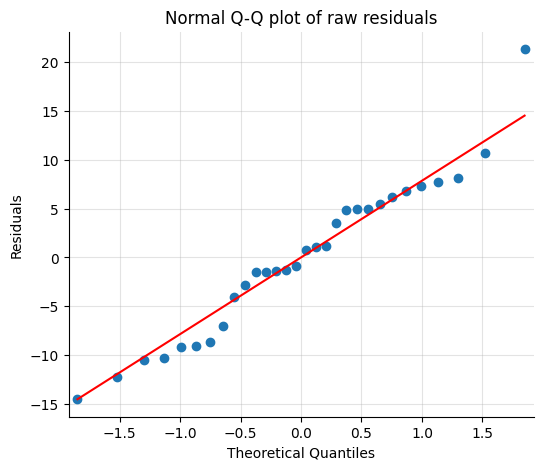

In [22]:
plot_raw_residual_qq(mlm)